In [1]:
import numpy as np
import matplotlib.pyplot as plt

HEALTHY = 0
SICK = 1
DEAD = 2

In [2]:
def simulate(N=15, R=3, S=0.5, D=0.1, T=200, seed=42):
    np.random.seed(seed)

    size = N + 1
    field = np.zeros((size, size), dtype=int)
    field[0, 0] = SICK

    healthy_history = []
    sick_history = []
    dead_history = []

    no_norm = None
    half_dead = None
    all_dead = None

    max_sicks_per_day = 0
    arg_max_sicks_per_day = 0

    total_population = size * size

    for t in range(T):
        new_field = field.copy()
        new_sicks_today = 0

        for i in range(size):
            for j in range(size):
                if field[i, j] == HEALTHY:
                    infected_neighbor = False

                    for x in range(max(0, i - R), min(size, i + R + 1)):
                        for y in range(max(0, j - R), min(size, j + R + 1)):
                            dist = np.sqrt((i - x)**2 + (j - y)**2)
                            if dist <= R and field[x, y] == SICK:
                                infected_neighbor = True
                                break
                        if infected_neighbor:
                            break
                    if infected_neighbor and np.random.rand() < S:
                        new_field[i, j] = SICK
                        new_sicks_today += 1
                elif field[i, j] == SICK:
                    if np.random.rand() < D:
                        new_field[i, j] = DEAD

        field = new_field
        healthy_count = np.sum(field == HEALTHY)
        sick_count = np.sum(field == SICK)
        dead_count = np.sum(field == DEAD)

        healthy_history.append(healthy_count)
        sick_history.append(sick_count)
        dead_history.append(dead_count)

        if no_norm is None and healthy_count == 0:
            no_norm = t

        if half_dead is None and dead_count >= total_population / 2:
            half_dead = t

        if all_dead is None and dead_count == total_population:
            all_dead = t

        if new_sicks_today > max_sicks_per_day:
            max_sicks_per_day = new_sicks_today
            arg_max_sicks_per_day = t

        if dead_count == total_population:
            break

    metrics = {
        "NO_NORM": no_norm,
        "HALF_DEAD": half_dead,
        "ALL_DEAD": all_dead,
        "MAX_SICKS_PER_DAY": max_sicks_per_day,
        "ARG_MAX_SICKS_PER_DAY": arg_max_sicks_per_day
    }

    history = {
        "healthy": healthy_history,
        "sick": sick_history,
        "dead": dead_history
    }

    return metrics, history

In [3]:
N = 15
R = 3
S = 0.5
D = 0.1
T = 200

metrics, history = simulate(N=N, R=R, S=S, D=D, T=T)

print("Метрики модели:")
for k, v in metrics.items():
    print(f"{k}: {v}")

Метрики модели:
NO_NORM: 14
HALF_DEAD: 12
ALL_DEAD: 54
MAX_SICKS_PER_DAY: 50
ARG_MAX_SICKS_PER_DAY: 5


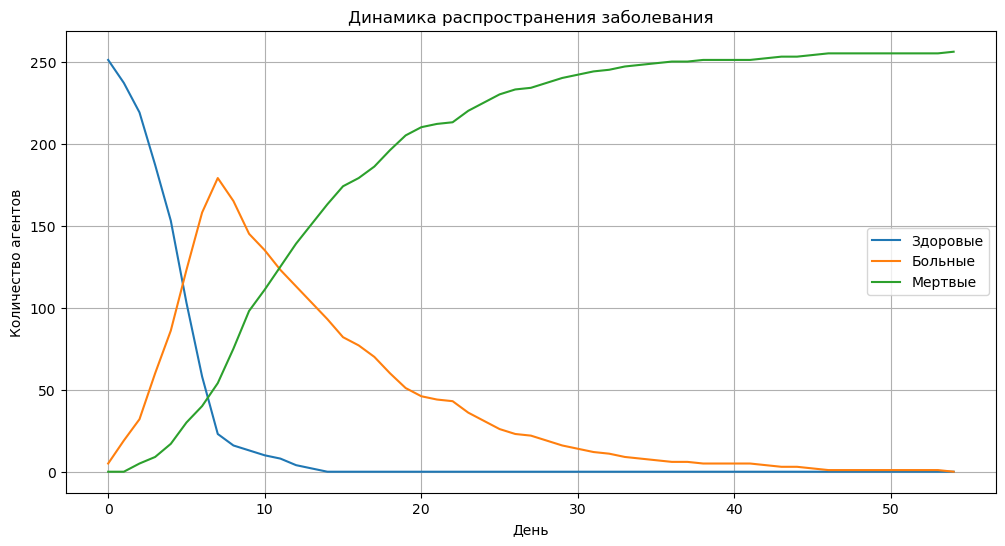

In [4]:
days = range(len(history["healthy"]))
plt.figure(figsize=(12, 6))
plt.plot(days, history["healthy"], label="Здоровые")
plt.plot(days, history["sick"], label="Больные")
plt.plot(days, history["dead"], label="Мертвые")
plt.xlabel("День")
plt.ylabel("Количество агентов")
plt.title("Динамика распространения заболевания")
plt.legend()
plt.grid()
plt.show()

In [5]:
def research_parameter(param_name, values,
                       N=15, R=3, S=0.5, D=0.1, T=200):
    no_norms = []
    half_deads = []
    all_deads = []
    for val in values:
        cur_R = R
        cur_S = S
        cur_D = D
        if param_name == "R":
            cur_R = val
        elif param_name == "S":
            cur_S = val
        elif param_name == "D":
            cur_D = val
        metrics, _ = simulate(
            N=N,
            R=cur_R,
            S=cur_S,
            D=cur_D,
            T=T
        )
        no_norms.append(
            metrics["NO_NORM"] if metrics["NO_NORM"] is not None else T
        )
        half_deads.append(
            metrics["HALF_DEAD"] if metrics["HALF_DEAD"] is not None else T
        )
        all_deads.append(
            metrics["ALL_DEAD"] if metrics["ALL_DEAD"] is not None else T
        )
    plt.figure(figsize=(10, 6))
    plt.plot(values, no_norms, marker='o', label="NO_NORM")
    plt.plot(values, half_deads, marker='o', label="HALF_DEAD")
    plt.plot(values, all_deads, marker='o', label="ALL_DEAD")
    plt.xlabel(param_name)
    plt.ylabel("День")
    plt.title(f"Зависимость метрик от параметра {param_name}")
    plt.legend()
    plt.grid()
    plt.show()

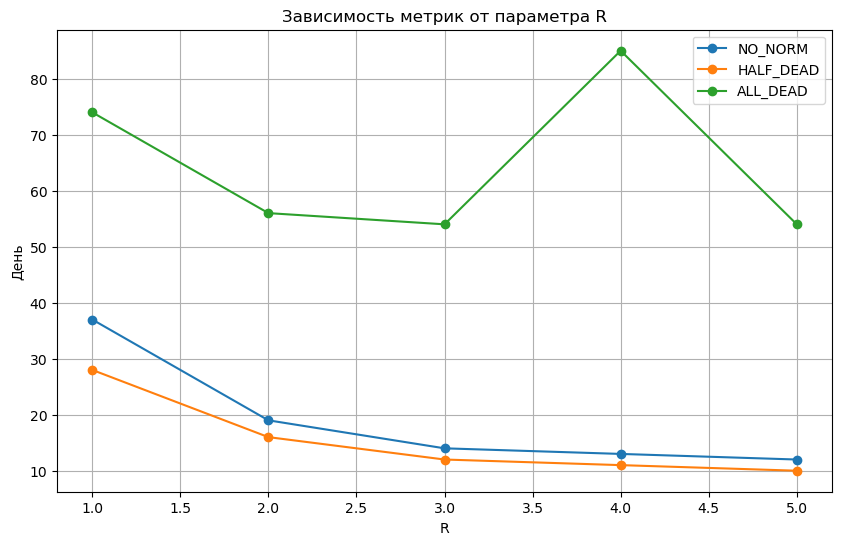

In [6]:
R_values = [1, 2, 3, 4, 5]
research_parameter("R", R_values)

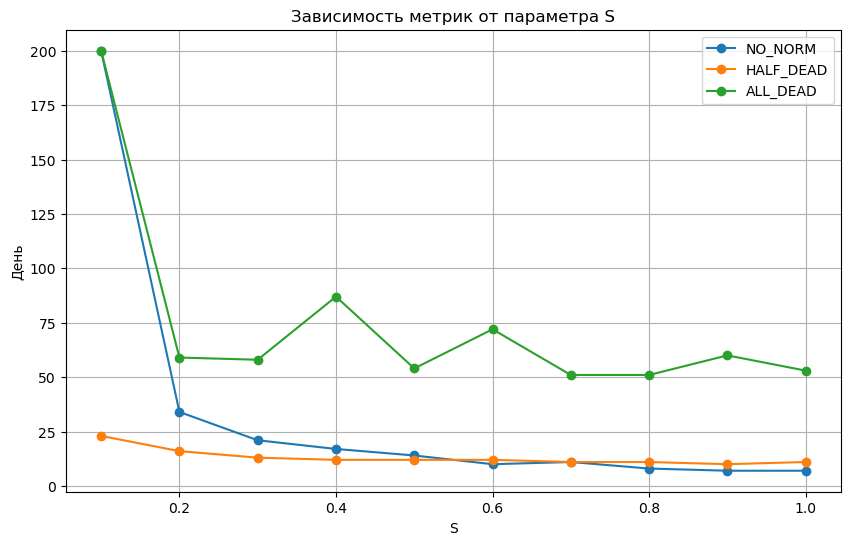

In [7]:
S_values = np.arange(0.1, 1.1, 0.1)
research_parameter("S", S_values)

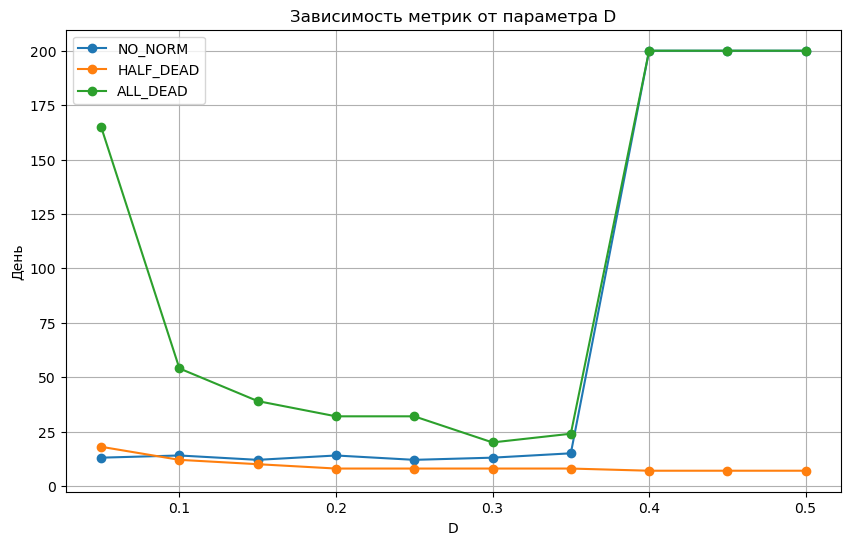

In [8]:
D_values = np.arange(0.05, 0.55, 0.05)
research_parameter("D", D_values)